# 03 — Frequency-Domain Feature Extraction

Applies FFT-based spectral analysis to the preprocessed (filtered + normalized) signals from notebook 02, to produce a tabular feature set for classification.

## Design decisions

| Decision | Choice | Why |
|---|---|---|
| Analysis unit | 60s windows, 30s step (50% overlap), sliced **within** each phase | Whole-phase FFT gives only ~140 rows (7 phases x 20 subjects), blends non-stationary dynamics within a phase, and produces variable-length inputs (40s-6.5min phases). Windowing fixes all three; phase boundaries still define window labels/limits. |
| Mini EmotionalStress (~40s) | Auto-dropped | Shorter than one window, so it naturally yields zero windows -- no label-based filtering needed (both EmotionalStress phases share the same annotation label). |
| HR / SpO2 (1 Hz) | Single-segment Welch, `nperseg=60, noverlap=0` | Only 60 samples per window -- sub-averaging would worsen the already-coarse resolution needed to resolve the HRV LF band (0.04-0.15 Hz). |
| EDA (8 Hz) | Single-segment Welch, `nperseg=480, noverlap=0` | The Posada-Quintero bands are only 0.03-0.1 Hz wide -- at the originally-planned 16s-averaged resolution (Delta-f=0.0625Hz) the tonic band got 0 bins and sympathetic_high got exactly 1 (silently zero under trapezoidal integration, found during verification). Full-window resolution (Delta-f~0.0167Hz) gives each band several bins, trading away variance reduction to make the bands representable at all. |
| Acc / Temp (8 Hz) | Averaged Welch, `nperseg=128 (16s), noverlap=64` | These bands are wide (movement: 0.5-4Hz) relative to Delta-f=0.0625Hz, so variance reduction from averaging is safe here without losing resolution. |
| STFT / spectrogram | Whole phase segments only, for visualization | Shows spectral content evolving across a full phase (minutes); not used as a tabular feature source. |
| Notebook 02's low-pass filter | **Split by channel group**: Acc and HR/SpO2 unfiltered, EDA/temp filtered at 1.0 Hz | Acc's movement band (0.5-4Hz) already reaches this record's 4Hz Nyquist -- no headroom for any cutoff. HR/SpO2's HF band already reaches 0.4Hz of the 0.5Hz Nyquist -- also no usable headroom. EDA/temp's own bands top out at 0.25Hz, leaving real headroom (0.25-4Hz), so they're filtered separately from Acc at the original 1.0 Hz cutoff -- safely above what EDA needs, removing some high-frequency noise for free. `load_and_preprocess_subject` takes independent `accel_cutoff`/`eda_temp_cutoff`/`spo2_hr_cutoff` (each `None`-able) so channel groups needing different treatment don't have to share one cutoff. |

See `thesis_notes.md` for the full reasoning, frequency-band literature basis, and limitations (ultra-short-term HRV resolution, HR spectrum computed from the bpm series rather than an RR-interval tachogram).

In [1]:
import sys
sys.path.insert(0, '..')

from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.preprocessing import (
    assemble_subject_rows,
    get_phase_segments,
    get_phase_windows,
    load_and_preprocess_subject,
    load_record,
    subject_paths,
)
from src.features import (
    ACC_BANDS,
    EDA_BANDS,
    HR_BANDS,
    compute_acc_magnitude,
    compute_spectrogram,
    extract_window_features,
)
from src.data_quality import audit_features, clean_features

In [2]:
WINDOW_SECONDS = 60
STEP_SECONDS = 30

print("Frequency bands used:")
print(f"  HR : {HR_BANDS}")
print(f"  EDA: {EDA_BANDS}")
print(f"  Acc: {ACC_BANDS}")

Frequency bands used:
  HR : {'lf': (0.04, 0.15), 'hf': (0.15, 0.4)}
  EDA: {'tonic': (0.01, 0.045), 'sympathetic_low': (0.045, 0.15), 'sympathetic_high': (0.15, 0.25)}
  Acc: {'postural': (0.0, 0.5), 'movement': (0.5, 4.0)}


## Validate the mini-phase auto-drop

Both `EmotionalStress` phases (the ~40s anticipation-only one and the full ~6min one) share the identical annotation label, so they can only be told apart by duration. Confirm, across all 20 subjects, that the mini phase is always shorter than one window and the full phase is always at least one window long -- this is what makes the mini phase drop out of `get_phase_windows` automatically.

In [3]:
for subject_id in range(1, 21):
    acc_temp_eda_path, _ = subject_paths(subject_id)
    record = load_record(acc_temp_eda_path, annotation_extension='atr')
    segments = get_phase_segments(record)
    emotional_stress_segments = [s for s in segments if s['label'] == 'EmotionalStress']
    durations = [len(s['signal']) / record['sampling_frequency'] for s in emotional_stress_segments]

    assert len(emotional_stress_segments) == 2, \
        f"Subject {subject_id}: expected 2 EmotionalStress segments, got {len(emotional_stress_segments)}"
    assert durations[0] < WINDOW_SECONDS, \
        f"Subject {subject_id}: mini EmotionalStress duration {durations[0]:.1f}s is not < {WINDOW_SECONDS}s"
    assert durations[1] >= WINDOW_SECONDS, \
        f"Subject {subject_id}: full EmotionalStress duration {durations[1]:.1f}s is not >= {WINDOW_SECONDS}s"

print(f"Validated 20 subjects: mini EmotionalStress phase always < {WINDOW_SECONDS}s (auto-dropped), "
      f"full phase always >= {WINDOW_SECONDS}s (kept).")

Validated 20 subjects: mini EmotionalStress phase always < 60s (auto-dropped), full phase always >= 60s (kept).


## Single-subject demo -- Subject 1

In [4]:
record_acc_temp_eda, record_spo2_hr = load_and_preprocess_subject(
    1, accel_cutoff=None, eda_temp_cutoff=1.0, spo2_hr_cutoff=None
)

windows_acc = get_phase_windows(record_acc_temp_eda, WINDOW_SECONDS, STEP_SECONDS)
windows_hr = get_phase_windows(record_spo2_hr, WINDOW_SECONDS, STEP_SECONDS)

counts_acc = Counter(w['label'] for w in windows_acc)
counts_hr = Counter(w['label'] for w in windows_hr)

print(f"AccTempEDA: {len(windows_acc)} windows total, per-phase: {dict(counts_acc)}")
print(f"SpO2HR    : {len(windows_hr)} windows total, per-phase: {dict(counts_hr)}")

AccTempEDA: 67 windows total, per-phase: {'Relax': 36, 'PhysicalStress': 9, 'CognitiveStress': 11, 'EmotionalStress': 11}
SpO2HR    : 67 windows total, per-phase: {'Relax': 36, 'PhysicalStress': 9, 'CognitiveStress': 11, 'EmotionalStress': 11}


## Extract frequency-domain features -- Subject 1 demo

In [5]:
demo_rows = assemble_subject_rows(
    record_acc_temp_eda, record_spo2_hr, WINDOW_SECONDS, STEP_SECONDS, extract_window_features
)
demo_features_df = pd.DataFrame(demo_rows)
demo_features_df.head()

,window_index,label,start_time,acc_total_power,acc_dominant_frequency,acc_spectral_entropy,acc_postural_power,acc_movement_power,acc_movement_ratio,eda_total_power,...,temp_spectral_entropy,hr_total_power,hr_dominant_frequency,hr_spectral_entropy,hr_lf_power,hr_hf_power,hr_lf_hf_ratio,spo2_total_power,spo2_dominant_frequency,spo2_spectral_entropy
0,0,Relax,0.0,0.001204,0.5000,2.829928,0.000881,0.000360,0.408438,3.115451e-07,...,1.842024,0.091124,0.016667,1.384307,0.020176,0.000698,28.908296,0.429833,0.066667,2.458527
1,1,Relax,30.0,0.006642,0.5000,2.469886,0.006261,0.001473,0.235234,2.625595e-06,...,2.011909,0.051705,0.016667,1.674680,0.025471,0.000568,44.818692,0.545319,0.016667,2.341080
2,2,Relax,60.0,0.042197,0.5000,1.254150,0.045611,0.001547,0.033913,1.089305e-06,...,1.878870,0.034357,0.016667,1.273045,0.009139,0.000574,15.919002,0.625043,0.016667,1.400758
3,3,Relax,90.0,0.000086,1.9375,4.070637,0.000009,0.000077,8.563217,6.427975e-07,...,2.428714,0.116725,0.016667,1.122270,0.012236,0.000642,19.061246,0.063967,0.016667,1.049340
4,4,Relax,120.0,0.000058,0.7500,4.060304,0.000005,0.000054,10.840780,2.941200e-08,...,2.469809,0.008920,0.033333,1.638110,0.002837,0.000470,6.035534,0.254088,0.033333,2.264591


### Sanity check -- do features separate Relax from stress phases?

Mean of a few key features per phase, before scaling up to all 20 subjects. Expect higher EDA sympathetic power, HR LF/HF ratio, and Acc movement power in stress phases vs. Relax.

In [6]:
demo_features_df.groupby('label')[[
    'eda_sympathetic_low_power', 'eda_sympathetic_high_power', 'hr_lf_hf_ratio', 'acc_movement_power',
]].mean()

,eda_sympathetic_low_power,eda_sympathetic_high_power,hr_lf_hf_ratio,acc_movement_power
label,,,,
CognitiveStress,0.007569,1.711579e-03,11.140308,0.006710
EmotionalStress,0.000110,1.764412e-05,11.953760,0.053893
PhysicalStress,0.000006,6.719163e-07,13.090212,0.070977
Relax,0.005046,2.610631e-03,13.296584,0.001057


## Spectrogram comparison -- Relax vs. stress

Computed over **whole phase segments** (not the 60s tabular-feature windows), to show how the spectrum evolves across an entire phase.

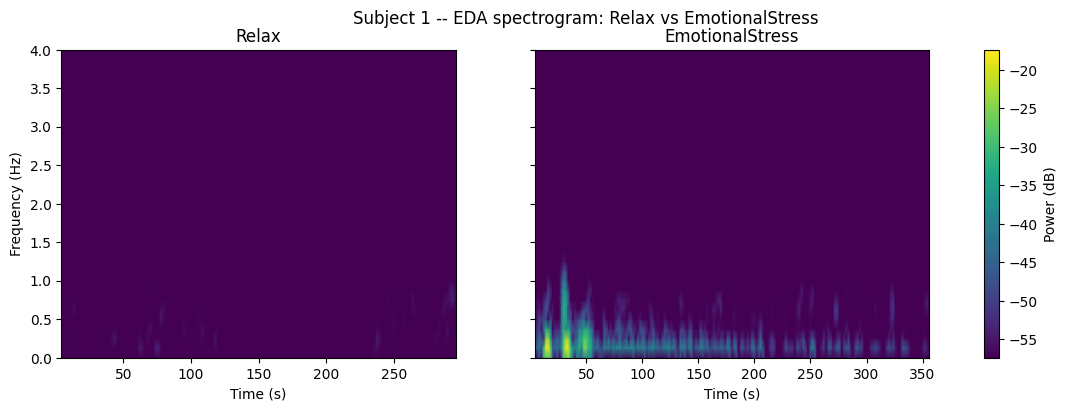

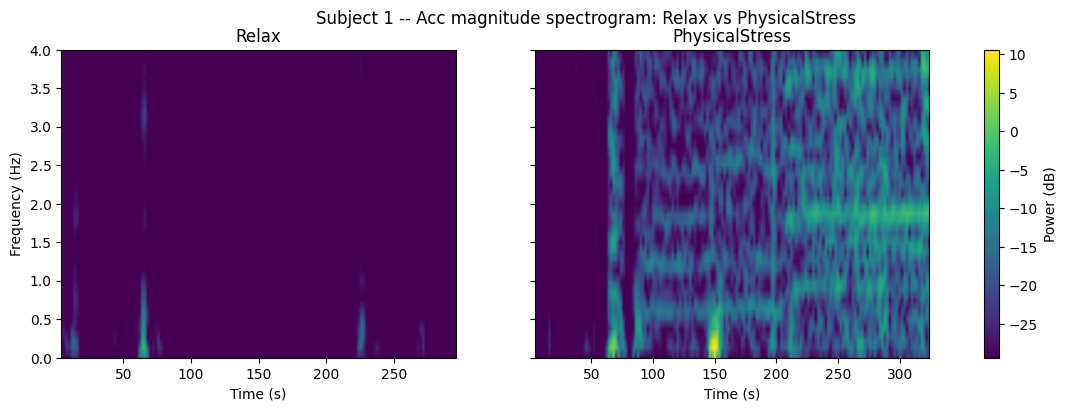

In [7]:
def plot_spectrogram_comparison(signal_a, signal_b, label_a, label_b, sampling_frequency, title, dynamic_range_db=40):
    """
    Plot two spectrograms side by side on a shared dB color scale.

    Raw linear power has too much dynamic range for a single-scale linear
    plot: one outlier bin (e.g. a movement artifact) sets vmax and crushes
    everything else -- including the sustained lower-power activity that's
    actually the interesting signal -- down to near-black. Converting to dB
    and showing a fixed window below the combined peak keeps that activity
    visible while still allowing a fair Relax-vs-stress comparison.
    """
    nperseg, noverlap = 64, 48
    freqs_a, times_a, sxx_a = compute_spectrogram(signal_a, sampling_frequency, nperseg, noverlap)
    freqs_b, times_b, sxx_b = compute_spectrogram(signal_b, sampling_frequency, nperseg, noverlap)

    epsilon = 1e-12
    sxx_a_db = 10 * np.log10(sxx_a + epsilon)
    sxx_b_db = 10 * np.log10(sxx_b + epsilon)

    vmax = max(sxx_a_db.max(), sxx_b_db.max())
    vmin = vmax - dynamic_range_db

    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
    mesh = None
    for ax, freqs, times, sxx_db, label in [
        (axes[0], freqs_a, times_a, sxx_a_db, label_a),
        (axes[1], freqs_b, times_b, sxx_b_db, label_b),
    ]:
        mesh = ax.pcolormesh(times, freqs, sxx_db, shading='gouraud', vmin=vmin, vmax=vmax, cmap='viridis')
        ax.set_title(label)
        ax.set_xlabel('Time (s)')
    axes[0].set_ylabel('Frequency (Hz)')
    fig.colorbar(mesh, ax=axes, label='Power (dB)')
    fig.suptitle(title)
    plt.show()


segments = get_phase_segments(record_acc_temp_eda)
signal_names = record_acc_temp_eda['signal_names']
fs = record_acc_temp_eda['sampling_frequency']

relax_segment = segments[0]
physical_stress_segment = segments[1]
emotional_stress_segment = segments[6]

eda_relax = relax_segment['signal'][:, signal_names.index('EDA')]
eda_emotional_stress = emotional_stress_segment['signal'][:, signal_names.index('EDA')]
plot_spectrogram_comparison(eda_relax, eda_emotional_stress, 'Relax', 'EmotionalStress', fs,
                             'Subject 1 -- EDA spectrogram: Relax vs EmotionalStress')

acc_mag_relax = compute_acc_magnitude(relax_segment['signal'], signal_names)
acc_mag_physical_stress = compute_acc_magnitude(physical_stress_segment['signal'], signal_names)
plot_spectrogram_comparison(acc_mag_relax, acc_mag_physical_stress, 'Relax', 'PhysicalStress', fs,
                             'Subject 1 -- Acc magnitude spectrogram: Relax vs PhysicalStress')

## Full dataset -- extract features for all 20 subjects

In [8]:
all_rows = []
for subject_id in range(1, 21):
    try:
        record_acc, record_hr = load_and_preprocess_subject(
            subject_id, accel_cutoff=None, eda_temp_cutoff=1.0, spo2_hr_cutoff=None
        )
        subject_rows = assemble_subject_rows(record_acc, record_hr, WINDOW_SECONDS, STEP_SECONDS, extract_window_features)
        for row in subject_rows:
            row['subject_id'] = subject_id
        all_rows.extend(subject_rows)
    except Exception as error:
        print(f"Subject {subject_id}: skipped due to error: {error}")

features_df = pd.DataFrame(all_rows)
print(f"Full dataset: {features_df.shape[0]} rows, {features_df.shape[1]} columns")

Full dataset: 1313 rows, 29 columns


## Data Quality — Missing and Bad Values

Checked here because this is the first point in the pipeline where the data is a real `pd.DataFrame` (`features_df` above) rather than the numpy arrays `src/preprocessing.py` works with internally. Two checks, both in `src/data_quality.py`:

- **Missing values** -- NaN/Inf per column.
- **Sanity bounds** -- power/entropy/ratio columns must be non-negative, and `*_dominant_frequency` columns must fall within their channel's Nyquist frequency, by construction (see `src/features.py`). A violation here is numerical noise on an otherwise-legitimate window, not a reason to discard it, so these get **clipped** to their valid bound rather than dropped.

In [9]:
METADATA_COLUMNS = ['window_index', 'label', 'start_time', 'subject_id']
FEATURE_COLUMNS = [c for c in features_df.columns if c not in METADATA_COLUMNS]

report = audit_features(features_df, FEATURE_COLUMNS)

print("Missing values: all zero" if report[['n_nan', 'n_inf']].sum().sum() == 0 else "Missing values found:")
print(report[['n_nan', 'n_inf']].sum())
print()
sanity_hits = report[report['n_violations'] > 0]
print(f"Sanity-bound violations ({sanity_hits['n_violations'].sum()} values, clipped not dropped):")
print(sanity_hits)

features_df = clean_features(features_df, FEATURE_COLUMNS)

Missing values: all zero
n_nan    0
n_inf    0
dtype: int64

Sanity-bound violations (118 values, clipped not dropped):
                       n_nan  n_inf    rule  n_violations
hr_spectral_entropy        0      0  >= 0.0             1
spo2_spectral_entropy      0      0  >= 0.0           117


## Save features

In [10]:
output_path = Path('../outputs/processed/frequency_features.csv')
output_path.parent.mkdir(parents=True, exist_ok=True)
features_df.to_csv(output_path, index=False)

print(f"Saved to {output_path}")
print(features_df.shape)
print()
print(features_df['label'].value_counts())
print()
print(features_df['subject_id'].value_counts())

Saved to ..\outputs\processed\frequency_features.csv
(1313, 29)

label
Relax              709
EmotionalStress    223
CognitiveStress    201
PhysicalStress     180
Name: count, dtype: int64

subject_id
11    73
20    72
1     67
2     66
3     66
5     66
8     66
7     65
9     65
10    65
14    65
15    65
18    65
4     64
6     64
12    64
13    64
16    64
19    64
17    63
Name: count, dtype: int64


## Limitations

- **HR/SpO2 spectral resolution** is bounded by 1 Hz sampling and the 60s window (frequency resolution ~0.017 Hz) -- this is "ultra-short-term HRV," not the canonical 5-minute-window HRV standard.
- **HR LF/HF is computed from the 1 Hz HR-in-bpm series**, not a canonical RR-interval tachogram -- an approximation given what this dataset provides, not true beat-to-beat HRV.
- **Mini EmotionalStress phase (~40s) is excluded** from the feature set, being shorter than one analysis window.
- **Accelerometer axes in this WFDB record are sampled at 8 Hz**, not the Empatica E4's native 32 Hz (see corrected note in `thesis_notes.md`) -- movement-band features are valid up to the 4 Hz Nyquist this implies.
- **Notebook 02's denoising low-pass filter is skipped for Acc and HR/SpO2** (`accel_cutoff=None, spo2_hr_cutoff=None`) -- their bands of interest (Acc 0.5-4Hz, HR/SpO2 LF/HF up to 0.4Hz) leave no headroom below each record's Nyquist for a cutoff to avoid touching them. **EDA/temp are still filtered** (`eda_temp_cutoff=1.0`), now independently of Acc, since their own bands top out at 0.25Hz -- well clear of the 1.0Hz cutoff.
- **EDA uses full-window (60s) resolution, not averaged 16s sub-segments**, because the Posada-Quintero bands are too narrow (0.03-0.1 Hz) to survive the coarser resolution -- caught during verification when `eda_sympathetic_high_power` and `eda_tonic_power` came out exactly zero for every row.